<style>
pre {
    white-space: pre-wrap !important;
    word-wrap: break-word !important;
    overflow-wrap: anywhere !important;
}

.highlight pre {
    white-space: pre-wrap !important;
}

.jp-CodeCell .jp-InputArea-editor {
    white-space: pre-wrap !important;
}
</style>

<h1 style="text-align: center;">Felicidad y otros factores</h1>

## Introducción

La felicidad de un país se puede medir basandose en diversos factores, sean sociales, económicos y de salud. El World Happiness Report ha medido, por varios años, el nivel de felicidad de los países y los posiciona según este nivel (World Happiness Report, 2026a). Este reporte combina factores como el Producto Interno Bruto (GDP por sus siglas en inglés), la esperanza de vida, el nivel de corrupción, etc., por lo que estos factores ayudan a explicar las diferencias o brechas que puede haber entre estos países (World Happiness Report, 2026b).

Se analizará la relación entre la felicidad de un país y su GDP utilizando una regresión lineal simple y, posteriormente, se realizará un modelo de regresión lineal múltiple empleando otros factores que la pueden afectar, como lo es la esperanza de vida, el desempleo y el control de la corrupción. 

La finalidad es evaluar si estas variables adicionales mejoran la capacidad del modelo para explicar las diferencias de felicidad entre países.

## Metodología
Para desarrollar el análisis de estos factores, se realizó una revisión de los datos para comprender su estructura, identificar la cantidad de los países incluidos y visualizar el comportamiento de las variables. Esto se hizo con la finalidad de definir la mejor manera de plantear los modelos de regresión lineal. Para llevar este proceso acabo se utilizó Jupyter Notebook y Python para la manipulación, análisis y visualización de los datos.

Para comenzar, se analizó la relación entre el nivel de felicidad y el GDP, y observando los datos de la Tabla 1, se puede inferir que tienen una relación positiva. Es decir, que los países que tienen un GDP alto también llegan a presentar niveles de felicidad altos. 

Sin embargo, solamente tomar en cuenta el GDP como la única variable explicativa del nivel de felicidad de un país es limitante, esto debido a que la felicidad también se influye por otros factores sociales o de salud presentes de manera distinta en los diversos países.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv("A1.2 Felicidad y GDP.csv")
data.head(141).style.hide(axis="index").set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th','props': [('text-align', 'center')]}]).set_caption("[TABLA 1]. Vista previa del conjunto de datos.")

Pais,Felicidad,GDP
Finland,7.821000,271837000000.000000
Denmark,7.636200,356085000000.000000
Iceland,7.557500,21718075725.000000
Switzerland,7.511600,752248000000.000000
Netherlands,7.414900,913865000000.000000
Luxembourg,7.404000,73353132794.000000
Sweden,7.384300,541487000000.000000
Norway,7.365100,362198000000.000000
Israel,7.363800,407101000000.000000
New Zealand,7.199800,211735000000.000000


En la Tabla 2, se observa un análisis descriptivo de las variables que corresponden a los datos observados en la tabla anterior. En esta tabla se puede observar que el conjunto de datos cuentan con 141 países y no hay valores faltantes en ninguna de las dos variables. El nivel de felicidad presenta una media de 5.56, con un valor mínimo de 2.40 y un valor máximo de 7.82.

Por otro lado, el GDP cuenta con una variación muy alta entre los países. Su media es de 58.9 mil millones y su mediana es de 6.2 mil millones, por lo que se observa una gran diferencia entre la media y mediana. Su valor máximo es de 2.09 billones, por lo que algunos países cuentan con un valor de GDP mucho más alto que el resto de los países. Esto puede significar que los datos económicos no tienen una distribución uniforme y será importante analizar su comportamiento antes de comenzar con el análisis en los modelos de regresión lineal.

In [59]:
data.drop(columns=["logGDP"]).describe().style.format("{:.2f}").set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th','props': [('text-align', 'center')]}]).set_caption("[TABLA 2]. Estadística descriptiva de los datos")

,Felicidad,GDP
count,141.00,141.00
mean,5.56,588994202378.14
std,1.10,2221611792399.31
min,2.40,1223876065.00
25%,4.89,18051170799.00
50%,5.59,62158002233.00
75%,6.31,345296000000.00
max,7.82,20893700000000.00


En la Gráfica 1, se observa que la mayoría de los países están en valores bajos de GDP, es decir, se concentran en el lado izquierdo de la gráfica. Por lo que hay pocos países que tienen valores más grandes y sus valores se encuentran muy alejados del resto de los datos. En cuanto a la felicidad, los datos se ven más dispersos y uniformes en la gráfica.

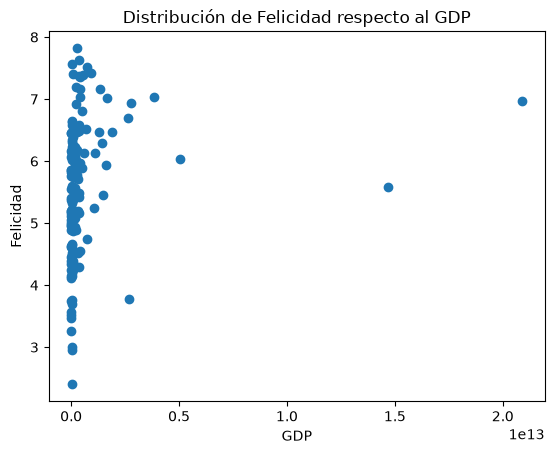

In [60]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.scatter(data["GDP"], data["Felicidad"])
plt.xlabel("GDP")
plt.ylabel("Felicidad")
plt.title("Distribución de Felicidad respecto al GDP")
plt.show()

[GRÁFICA 1]. Distribución de la felicidad respecto al GDP.

Debido a la gran diferencia entre los valores de GDP, se decidió aplicar una transformación logarítimica al GDP. Esta transformación logra reducir el efecto de los valores altos en los datos generales y consigue distribuir los datos de una manera más uniforme en la gráfica. 

Por lo que se volvió a analizar la relación entre log(GDP) y la felicidad para observar si los datos representan un comportamiento más lineal y adecuado para aplicar un modelo de regresión lineal. 

Ahora en la Gráfica 2, los datos se distribuyen de una manera más uniforme a lo largo del eje horizontal. Y también en la gráfica se observa una tendencia positiva más clara, conforme aumenta log(GDP) también aumenta la felicidad. 

Aunque los puntos se ven dispersos, la relación ahora se observa con un comportamiento lineal a comparación con el GDP en la escala original. Por lo tanto, utilizar log(GDP) es adecuado para realizar el modelo de regresión lineal. 

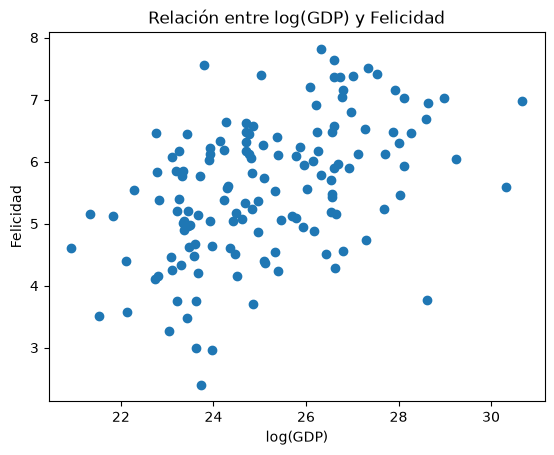

In [61]:
import numpy as np
import matplotlib.pyplot as plt

data["logGDP"] = np.log(data["GDP"])

%matplotlib inline

plt.scatter(data["logGDP"], data["Felicidad"])
plt.xlabel("log(GDP)")
plt.ylabel("Felicidad")
plt.title("Relación entre log(GDP) y Felicidad")
plt.show()

[GRÁFICA 2]. Relación entre log(GDP) y Felicidad

### Modelo de regresión lineal simple
Para el modelo de regresión lineal simple se seleccionó log(GDP) como variable explicativa y Felicidad como variable de respuesta. Se escogió log(GDP) como variable explicativo debido a que, después de la transformación logarítimica, los datos mostraron una distribución más uniforme en la gráfica y un comportamiento más lineal a comparación de GDP en su escala original. 

Por lo que, el modelo obtenido fue: 
Felicidad = β0 + β1⋅log(GDP)

In [38]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
data["logGDP"] = np.log(data["GDP"])
x = data["logGDP"]
y = data["Felicidad"]

model = sm.OLS(y, sm.add_constant(x))
results = model.fit()

tabla_regresion = pd.DataFrame({"Coeficiente": [results.params.iloc[0],results.params.iloc[1],None],
    "Error estándar": [results.bse.iloc[0],results.bse.iloc[1],None],
    "t": [results.tvalues.iloc[0],results.tvalues.iloc[1],None],
    "p-value": [results.pvalues.iloc[0],results.pvalues.iloc[1],None],
    "R²": [None,None,results.rsquared],
    "R² ajustado": [None,None,results.rsquared_adj],
    "F": [None,None,results.fvalue],
    "p-value F": [None,None,results.f_pvalue]}, index=["Intercepto", "log(GDP)", "Modelo"])

tabla_regresion.style.format("{:.4f}", na_rep="").set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th','props': [('text-align', 'center')]}]).set_caption("[TABLA 3]. Resultados de la regresión lineal simple")

,Coeficiente,Error estándar,t,p-value,R²,R² ajustado,F,p-value F
Intercepto,-1.3024,1.0938,-1.1907,0.2358,,,,
log(GDP),0.2728,0.0434,6.2917,0.0000,,,,
Modelo,,,,,0.2217,0.2161,39.5860,0.0000


A partir de los datos obtenidos en la Tabla 3, se observa que el coeficiente de log(GDP) es 0.2728, lo que signfiica que hay una relación positiva entre log(GDP) y Felicidad. Además, el p-value de log(GDP) es de 0.0000, por lo que es menor a 0.05 y su relación es estadísticamente significativa.

Asimismo, este modelo presenta un R^2 de 0.2217, esto significa que log(GDP) explica alrededor de un 22.17% de la variación en la felicidad. El p-value del estadístico F también es menor a 0.05 y esto indica que el modelo de regresión en conjunto es estadísticamente significativo también. 

No obstante, el intercepto tiene un p-value de 0.2358, por lo que no es estadísticamente significativo, pero este resultado no afecta la significancia de la relación entre log(GDP) y la felicidad. 

### Modelo de regresión lineal múltiple
Con el objetivo de representar de manera más completa los factores relacionados con la felicidad, se incorporaron tres variables adicionales: esperanza de vida, desempleo y control de la corrupción. La esperanza de vida es un indicador relacionado con la salud de la población, el desempleo como un factor económico y social, y el control de la corrupción como una variable institucional. 

Estas variables se añadieron al conjunto de datos original, utilizando el país como elemento común entre los distintos archivos. Para realizar el modelo de regresión lineal múltiple se utilizaron los países que contaban con la información completa para todas las variables utilizadas. Esto puede llegar a reducir el tamaño de la muestra y, por ende, puede disminuir la cantidad de información disponible para el análisis. Además, si los países que fueron eliminados presentan características diferentes a los de la muestra, los resultados podrían verse afectados y pueden llegar a ser menos representativos del conjunto original. 

De esta manera, el modelo de regresión lineal múltiple usó como variables explicativas log(GDP), esperanza de vida, desempleo y control de la corrupción, mientras que la felicidad se mantuvo como variable de respuesta. 

#### Control de la corrupción
Esta variable se utilizó para representar una dimensión institucional de los países. Se obtuvieron datos de los Worldwide Governance Indicators del Banco Mundial (Banco Mundial, 2026a), donde el indicador de control de la corrupción presenta valores de -2.5 a 2.5, en el cual los valores mayores representan mejores resultados de gobernanza. Esta variable también se relaciona con el análisis de la felicidad, debido a que la percepción de la corrupción es uno de los factores considerados en el World Happines Report (Gutiérrez Alcalá, 2023). 

Los datos obtenidos se pueden observar en la Tabla 4. 

In [63]:
datos_1 = pd.read_csv("controlcorrupcion.csv")
datos_1.head(141).style.hide(axis="index").set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th','props': [('text-align', 'center')]}]).set_caption("[TABLA 4]. Vista previa del conjunto de datos de la variable 'Control de Corrupción'.")

Pais,ControlCorrupcion
Aruba,1.165722
Afghanistan,-1.400890
Angola,-0.891832
Albania,-0.659431
United Arab Emirates,1.061431
Argentina,-0.134470
Armenia,0.105608
American Samoa,1.179799
Antigua and Barbuda,0.219916
Australia,1.603824


#### Desempleo
El desempleo se incorporó como un factor económico y social, utilizadno datos del Banco Mundial que se originan de estimaciones modeladas de la Organización Internacional del Trabajo (Banco Mundial, 2026b). Su relación con la felicidad es debido a que el desempleo, en un nivel individual y social, se ha relacionado negativamente con el bienestar y la felicidad de las personas (Ritzen, 2026).

In [54]:
datos_2 = pd.read_csv("desempleo.csv")
datos_2.head(141).style.hide(axis="index").set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th','props': [('text-align', 'center')]}]).set_caption("[TABLA 5]. Vista previa del conjunto de datos de la variable 'Desempleo'.")

Pais,Desempleo
Africa Eastern and Southern,7.539233
Afghanistan,13.351000
Angola,14.108000
Albania,10.926000
United Arab Emirates,2.174000
Argentina,7.145000
Armenia,12.871000
Australia,4.090000
Austria,5.582000
Azerbaijan,5.457000


#### Esperanza de vida
La esperanza de vida se seleccionó como un indicador relacionado con la salud y las condiciones de vida de la población. Los datos fueron obtenidos del Banco Mundial mediante el indicador 'Life expectancy at birth, total (years)' (Banco Mundial, 2026c). La inclusión de esta variable en el conjunto de datos se justifica debido a que el World Happiness Report considera la esperanza de vida saludable como uno de los factores utilizados para analizar los niveles de felicidad en los países (Gutiérrez Alcalá, 2023).

In [42]:
datos_3 = pd.read_csv("esperanza.csv")
datos_3.head(141).style.hide(axis="index").set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th','props': [('text-align', 'center')]}]).set_caption("[TABLA 6]. Vista previa del conjunto de datos de la variable 'Esperanza de vida'.")

Pais,Esperanza de vida
Afghanistan,66.289000
Albania,79.776000
Andorra,84.188000
United Arab Emirates,83.069000
Argentina,77.543000
Armenia,78.319512
Australia,83.051220
Austria,81.995122
Azerbaijan,74.576000
Belgium,82.300000


A continuación, se combinarán los distintos conjuntos de datos utilizando al país como elemento común. Por ende, a cada país del conjunto original se le asignaron valores de esperanza de vida, desempleo y control de la corrupción. 

Aunque el conjunto original estaba conformado por 141 países, después de unir los datos, la muestra final quedó formada por 130 países. Esto implica una pérdida relativamente pequeña de información, ya que se conserva una muy buena parte de la muestra original. Sin embargo, trabajar con una muestra menor puede reducir la capacidad del modelo para representar a todos los países originalmente incluidos.

Ahora el modelo se describe de la siguiente manera: 
Felicidad = β0 + β1⋅log(GDP) + β2⋅Esperanza de vida + β3⋅Desempleo + β4⋅Control de corrupción + ε

In [55]:
# Unir solo países presentes en todos los archivos
data_completa = pd.merge(data, datos_1, on="Pais", how="inner")
data_completa = pd.merge(data_completa, datos_2, on="Pais", how="inner")
data_completa = pd.merge(data_completa, datos_3, on="Pais", how="inner")

# Eliminar países que todavía tengan datos faltantes
data_modelo = data_completa.dropna(
    subset=[
        "Felicidad",
        "logGDP",
        "Esperanza de vida",
        "Desempleo",
        "ControlCorrupcion"])

In [57]:
import statsmodels.api as sm

x = data_modelo[["logGDP", "Esperanza de vida", "Desempleo", "ControlCorrupcion"]]

y = data_modelo["Felicidad"]

x = sm.add_constant(x)

model = sm.OLS(y, x)
results = model.fit()

tabla_multiple = pd.DataFrame({"Coeficiente": [results.params.iloc[0],results.params.iloc[1],results.params.iloc[2],results.params.iloc[3],results.params.iloc[4],None],
    "Error estándar": [results.bse.iloc[0],results.bse.iloc[1],results.bse.iloc[2],results.bse.iloc[3],results.bse.iloc[4],None],
    "t": [results.tvalues.iloc[0],results.tvalues.iloc[1],results.tvalues.iloc[2],results.tvalues.iloc[3],results.tvalues.iloc[4],None],
    "p-value": [results.pvalues.iloc[0],results.pvalues.iloc[1],results.pvalues.iloc[2],results.pvalues.iloc[3],results.pvalues.iloc[4],None],
    "R²": [None,None,None,None,None,results.rsquared],
    "R² ajustado": [None,None,None,None,None,results.rsquared_adj],
    "F": [None,None,None,None,None,results.fvalue],
    "p-value F": [None,None,None,None,None,results.f_pvalue]}, index=["Intercepto","log(GDP)","Esperanza de vida","Desempleo","Corrupción","Modelo"])

tabla_multiple.style.format("{:.4f}", na_rep="").set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th','props': [('text-align', 'center')]}]).set_caption("[TABLA 7]. Resultados de la regresión lineal múltiple")

,Coeficiente,Error estándar,t,p-value,R²,R² ajustado,F,p-value F
Intercepto,-0.9751,1.0058,-0.9695,0.3342,,,,
log(GDP),0.0313,0.0375,0.8362,0.4046,,,,
Esperanza de vida,0.0812,0.0114,7.1239,0.0000,,,,
Desempleo,-0.0441,0.0117,-3.7825,0.0002,,,,
Corrupción,0.2923,0.0782,3.7399,0.0003,,,,
Modelo,,,,,0.6639,0.6531,61.7279,0.0000


Los resultados observados en la Tabla 7 muestran que el modelo de regresión lineal múltiple es estadísticamente significativo, debido a que el p-value asociado al estadístico F es 0.0000 y, por lo tanto, menor a 0.05. Asimismo, el modelo presenta un R^2 de 0.6639, indicando que las variables incluidas explican un 66.39% de la variación observada en la felicidad de los países.

Al analizar cada variable de manera individual, la esperanza de vida presenta un coeficiente de 0.0812 y tiene un p-value menor a 0.05, por lo que tiene una asociación positiva y estadísticamente significativa con la felicidad. Por otro lado, el desempleo tiene un coeficiente de -0.0441, por lo que se relaciona con una disminución en la felicidad y también tiene un p-value menor a 0.05. Finalmente, el control de la corrupción tiene un coeficiente positivo de 0.2923 y es estadísticamente significativo, esto indica que un control de la corrupción se relaciona con niveles más altos de felicidad.

Por el contrario, log(GDP) presenta un p-value de 0.4046, lo que significa que no es estadísticamente significativo al considerar las demás variables en el modelo. Esto indica que en este modelo, no existe evidencia suficiente para afirmar que log(GDP) aporte una explicación adicional de la felicidad, una vez tomadas en cuenta la esperanza de vida, el desempleo y el control de la corrupción.

### Comparación de modelos
Al comparar ambos modelos, se observa una mejora importante en la capacidad explicativa gracias a la comparación de variables adicionales. El modelo de regresión lineal simple presentó un R^2 de 0.2217, por lo que log(GDP) explicó el 22.17% de la variación en la felicidad. El modelo de regresión lineal múltiple obtuvo un R^2 de 0.6639, por lo que se explica un 66.39% de la variación. Esto demuestra que considerar factores relacionados con la salud, el empleo y las instituciones permite una mejor representación de mejor manera las diferencias de felicidad entre países. 

También se observó que log(GDP) fue significativo en el modelo simple, pero dejó de serlo al agregar las demás variables. Esto indica que su relación con la felicidad puede estar relacionada con otros factores del modelo.

Entre las limitaciones observadas durante el análisis, la muestra se redujo de 141 a 130 países. Además, el modelo no incluye todos los factores que pueden influir en la felicidad y los resultados muestran asociaciones entre los datos y no causas entre los mismos.

Como trabajo futuro, se podrían incorporar otras variables sociales e institucionales y utilizar modelos más flexibles para estudiar relaciones que no necesariamente sean lineales.

### Conclusiones
A partir del análisis realizado se observó que existe una relación positiva entre el nivel de felicidad y el GDP, aunque en el modelo de regresión lineal simple explicó un 22.17% de la variación de la felicidad. Esto demuestra que el valor del GDP por sí solo no es suficiente para representar la felicidad de los países.

Al incorporar la esperanza de vida, el desempleo y el control de la corrupción, el modelo de regresión lineal aumentó su explicación de la variación de la felicidad de un 22.17% a un 66.39%La esperanza de vida y el control de la corrupción mostraron relaciones positivas con la felicidad, pero el desempleo presentó una relación negativa. 

En conclusión, los resultados demuestran que la felicidad de un país está relacoinada con distintos factores y no solamente con su situación económica. 

### Referencias
Banco Mundial. (2026a, 16 de agosto). Control of corruption: Governance estimate (approx. -2.5 to +2.5). World Bank Open Data. https://data.worldbank.org/indicator/GOV_WGI_CC_EST

Banco Mundial. (2026b, 16 de agosto). Desempleo, total (% de la fuerza laboral total) (estimación modelada de la OIT). World Bank Open Data. https://data.worldbank.org/indicator/SL.UEM.TOTL.ZS

Banco Mundial. (2026c, 16 de agosto). Esperanza de vida al nacer, total (años). Datos del Banco Mundial. https://datos.bancomundial.org/indicador/SP.DYN.LE00.IN

Gutiérrez Alcalá, R. (2023, 25 de mayo). La felicidad: ¿cómo se mide y se alcanza? Gaceta UNAM.

OpenAI. (2026). ChatGPT (GPT-5.6 Sol) [Modelo de lenguaje de gran escala].

Ritzen, J. (2026, 16 de agosto). La felicidad como guía para políticas del mercado laboral. IZA World of Labour.

World Happiness Report. (2026a, 16 de agosto). About us. University of Oxford. https://www.worldhappiness.report/about/

World Happiness Report. (2026b, 16 de agosto). World Happiness Report Dashboard. https://data.worldhappiness.report/table